# Import Library

In [11]:
import cv2
import os
import numpy as np
from tqdm import tqdm


# Visualisasi Data Mentah

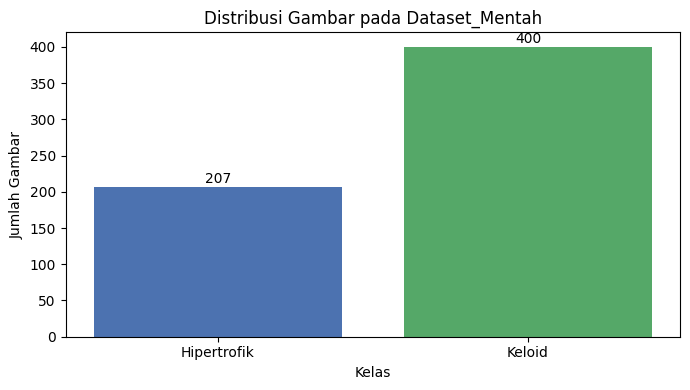

Distribusi Dataset_Mentah: {'Hipertrofik': 207, 'Keloid': 400}


In [12]:
import matplotlib.pyplot as plt

valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif")
KELAS_MINORITAS = "Hipertrofik"
KELAS_MAYORITAS = "Keloid"

DIR_MENTAH_HIPER = r"Dataset_Mentah/hypertrophic scars"
DIR_MENTAH_KELOID = r"Dataset_Mentah/keloid scars"

def hitung_gambar_valid(folder, ekstensi_valid=valid_ext):
    if not os.path.exists(folder):
        return 0
    return len([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(ekstensi_valid)
    ])

distribusi_mentah = {
    KELAS_MINORITAS: hitung_gambar_valid(DIR_MENTAH_HIPER),
    KELAS_MAYORITAS: hitung_gambar_valid(DIR_MENTAH_KELOID)
}

plt.figure(figsize=(7, 4))
bars = plt.bar(distribusi_mentah.keys(), distribusi_mentah.values(), color=["#4C72B0", "#55A868"])
plt.title("Distribusi Gambar pada Dataset_Mentah")
plt.ylabel("Jumlah Gambar")
plt.xlabel("Kelas")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y + 1, f"{int(y)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("Distribusi Dataset_Mentah:", distribusi_mentah)

# Deteksi Blur

In [13]:
def hitung_ketajaman(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# Crop & Resize

In [14]:
def resize_tanpa_distorsi(image_rgb, target_size=224):
    tinggi_asli, lebar_asli = image_rgb.shape[:2]
    
    rasio = float(target_size) / max(tinggi_asli, lebar_asli)
    ukuran_baru = (int(lebar_asli * rasio), int(tinggi_asli * rasio))
    
    gambar_dikecilkan = cv2.resize(image_rgb, ukuran_baru)
    
    sisa_lebar = target_size - ukuran_baru[0]
    sisa_tinggi = target_size - ukuran_baru[1]
    
    atas = sisa_tinggi // 2
    bawah = sisa_tinggi - atas
    kiri = sisa_lebar // 2
    kanan = sisa_lebar - kiri
    
    warna_bingkai = [0, 0, 0]
    gambar_final = cv2.copyMakeBorder(gambar_dikecilkan, atas, bawah, kiri, kanan, 
                                      cv2.BORDER_CONSTANT, value=warna_bingkai)
    return gambar_final

# Main Pipeline

In [15]:
def proses_dataset_mentah(folder_input, folder_output, batas_blur=10.0):
    if not os.path.exists(folder_input):
        print(f"Input folder not found: {folder_input}")
        return

    folder_sukses = os.path.join(folder_output, "sukses_diproses")
    folder_gagal = os.path.join(folder_output, "dibuang_karena_blur")
    os.makedirs(folder_sukses, exist_ok=True)
    os.makedirs(folder_gagal, exist_ok=True)

    try:
        exts = valid_ext
    except NameError:
        exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')

    daftar_file = [
        f for f in os.listdir(folder_input)
        if os.path.isfile(os.path.join(folder_input, f)) and f.lower().endswith(exts)
    ]

    print(f"Memproses {len(daftar_file)} gambar dari: {folder_input}")

    sukses_cnt = 0
    gagal_cnt = 0
    for nama_file in tqdm(daftar_file, desc="Processing", unit="file"):
        path_file = os.path.join(folder_input, nama_file)

        gambar_bgr = cv2.imread(path_file)
        if gambar_bgr is None:
            print(f"Unable to read image: {path_file}")
            continue

        try:
            if hitung_ketajaman(gambar_bgr) < batas_blur:
                cv2.imwrite(os.path.join(folder_gagal, nama_file), gambar_bgr)
                gagal_cnt += 1
                continue

            gambar_rgb = cv2.cvtColor(gambar_bgr, cv2.COLOR_BGR2RGB)
            gambar_siap_ai = resize_tanpa_distorsi(gambar_rgb, target_size=224)
            gambar_disimpan = cv2.cvtColor(gambar_siap_ai, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(folder_sukses, nama_file), gambar_disimpan)
            sukses_cnt += 1

        except Exception as e:
            print(f"Error processing {path_file}: {e}")
            try:
                cv2.imwrite(os.path.join(folder_gagal, nama_file), gambar_bgr)
                gagal_cnt += 1
            except Exception:
                pass

    print(f"Selesai: sukses={sukses_cnt}, gagal={gagal_cnt}")

# Cleaning

In [16]:
DIR_BERSIH_KELOID = r"Dataset_Bersih/keloid scars"
DIR_BERSIH_HIPER = r"Dataset_Bersih/hypertrophic scars"

os.makedirs(DIR_BERSIH_KELOID, exist_ok=True)
os.makedirs(DIR_BERSIH_HIPER, exist_ok=True)

print("--- Start cleaning majority class ---")
proses_dataset_mentah(
    folder_input=DIR_MENTAH_KELOID,
    folder_output=DIR_BERSIH_KELOID,
    batas_blur=10.0
)

print("\n--- Start cleaning minority class ---")
proses_dataset_mentah(
    folder_input=DIR_MENTAH_HIPER,
    folder_output=DIR_BERSIH_HIPER,
    batas_blur=10.0
)

print("\nPreprocessing finished.")

--- Start cleaning majority class ---
Memproses 400 gambar dari: Dataset_Mentah/keloid scars


Processing: 100%|██████████| 400/400 [00:02<00:00, 173.39file/s]


Selesai: sukses=395, gagal=5

--- Start cleaning minority class ---
Memproses 207 gambar dari: Dataset_Mentah/hypertrophic scars


Processing: 100%|██████████| 207/207 [00:00<00:00, 218.79file/s]

Selesai: sukses=201, gagal=6

Preprocessing finished.


# Visualisasi Dataset Bersih vs Blur

In [17]:
def hitung_file_gambar(folder, ekstensi=valid_ext):
    if not os.path.exists(folder):
        return 0
    return len([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(ekstensi)
    ])

def ambil_daftar_gambar(folder, ekstensi=valid_ext):
    if not os.path.exists(folder):
        return []
    return [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(ekstensi)
    ]

In [18]:
folder_map = {
    KELAS_MINORITAS: {
        "bersih": os.path.join(DIR_BERSIH_HIPER, "sukses_diproses"),
        "blur": os.path.join(DIR_BERSIH_HIPER, "dibuang_karena_blur"),
    },
    KELAS_MAYORITAS: {
        "bersih": os.path.join(DIR_BERSIH_KELOID, "sukses_diproses"),
        "blur": os.path.join(DIR_BERSIH_KELOID, "dibuang_karena_blur"),
    },
}

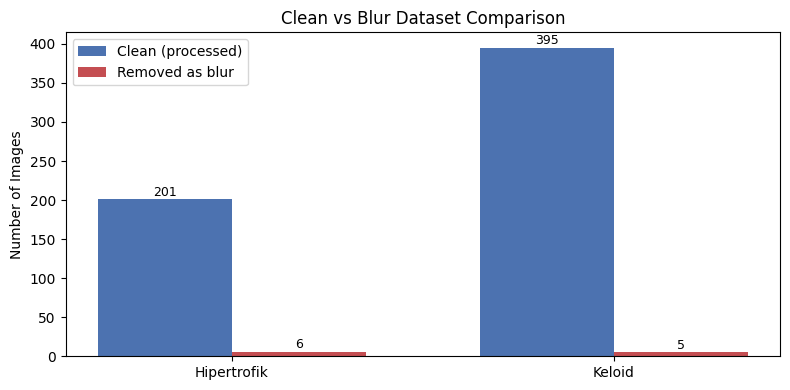

Count summary:
- Hipertrofik: clean=201, blur=6
- Keloid: clean=395, blur=5


In [19]:
kelas_list = list(folder_map.keys())
jumlah_bersih = [hitung_file_gambar(folder_map[k]["bersih"]) for k in kelas_list]
jumlah_blur = [hitung_file_gambar(folder_map[k]["blur"]) for k in kelas_list]

x = np.arange(len(kelas_list))
w = 0.35

plt.figure(figsize=(8, 4))
bars1 = plt.bar(x - w / 2, jumlah_bersih, width=w, label="Clean (processed)", color="#4C72B0")
bars2 = plt.bar(x + w / 2, jumlah_blur, width=w, label="Removed as blur", color="#C44E52")

plt.xticks(x, kelas_list)
plt.ylabel("Number of Images")
plt.title("Clean vs Blur Dataset Comparison")
plt.legend()

for b in list(bars1) + list(bars2):
    h = b.get_height()
    plt.text(b.get_x() + b.get_width() / 2, h + 1, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("Count summary:")
for k in kelas_list:
    print(f"- {k}: clean={hitung_file_gambar(folder_map[k]['bersih'])}, blur={hitung_file_gambar(folder_map[k]['blur'])}")

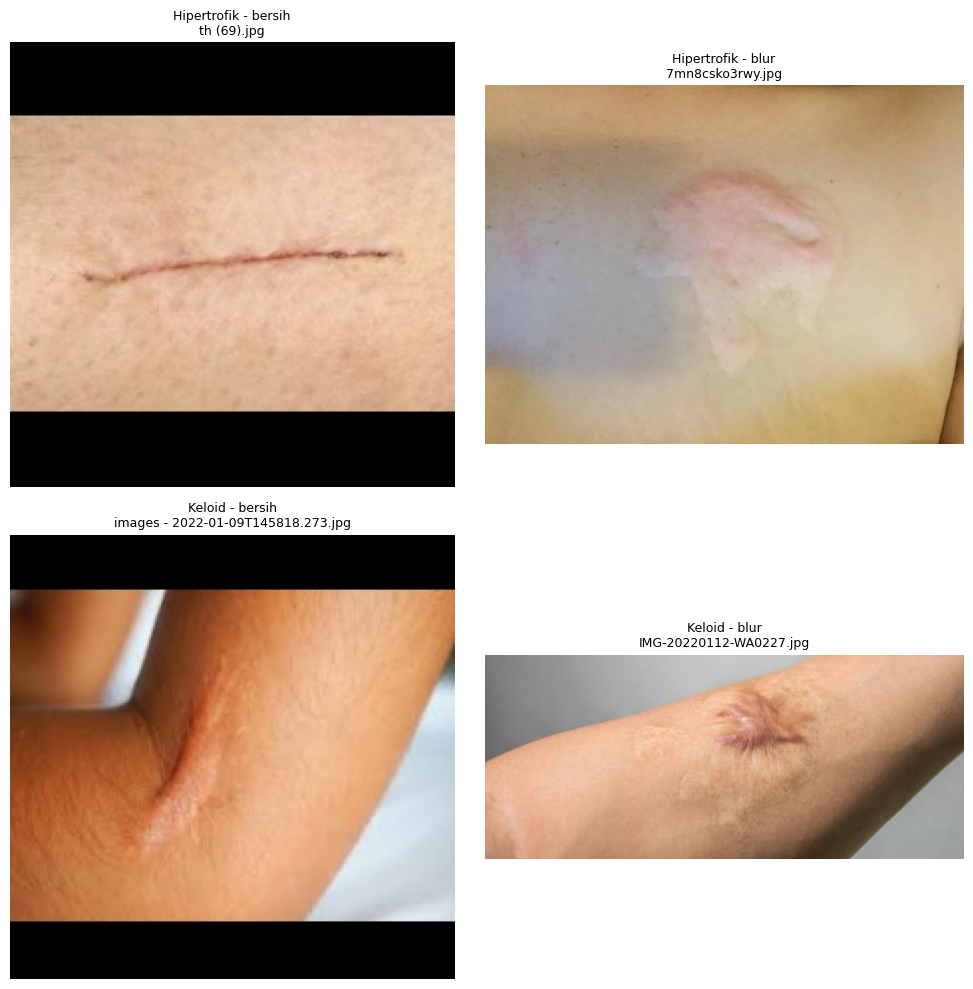

In [20]:
def tampilkan_contoh_gambar(folder, judul, n=1):
    file_gambar = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(valid_ext)
    ]
    if len(file_gambar) == 0:
        return None, None

    sample = np.random.choice(file_gambar, size=min(n, len(file_gambar)), replace=False)
    return sample[0], os.path.join(folder, sample[0])

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, kelas_nama in enumerate(kelas_list):
    for j, tipe in enumerate(["bersih", "blur"]):
        folder = folder_map[kelas_nama][tipe]
        nama_file, path_file = tampilkan_contoh_gambar(folder, f"{kelas_nama} - {tipe}")

        ax = axes[i, j]
        if path_file is None:
            ax.set_title(f"{kelas_nama} - {tipe}\n(Tidak ada gambar)")
            ax.axis("off")
            continue

        img_bgr = cv2.imread(path_file)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(f"{kelas_nama} - {tipe}\n{nama_file}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.show()